In [183]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def _parse_int_list(s):
    s = str(s).strip().strip('"').strip("'")
    if not s:
        return []

    return [int(x.strip()) for x in s.split(",") if x.strip() != ""]


def load_many_csvs(csv_glob_pattern: str) -> pd.DataFrame:
    paths = sorted(glob.glob(csv_glob_pattern))
    if not paths:
        raise FileNotFoundError(f"No CSV files match: {csv_glob_pattern}")

    dfs = []
    for p in paths:
        print("Loading:", p)
        df = pd.read_csv(p)
        df["__source_file__"] = p
        dfs.append(df)

    all_df = pd.concat(dfs, ignore_index=True)

    needed = {"pdb_id", "n_residues", "residue_ids", "cluster_ids", "K", "__source_file__"}
    missing = needed - set(all_df.columns)
    if missing:
        raise ValueError(f"Missing columns: {missing}")

    return all_df

def pick_common_pdb_id(df: pd.DataFrame, min_files: int = 2, seed: int | None = None) -> str:
    # count unique source files per pdb_id
    counts = df.groupby("pdb_id")["__source_file__"].nunique()
    candidates = counts[counts >= min_files].index.tolist()
    if not candidates:
        raise ValueError(f"No pdb_id appears in >= {min_files} different files.")
    rng = np.random.default_rng(seed)
    return candidates[int(rng.integers(0, len(candidates)))]

def _row_to_dense_track(row: pd.Series, n_res_target: int | None = None) -> np.ndarray:
    n_res = int(row["n_residues"])
    K = int(row["K"])

    residue_ids = _parse_int_list(row["residue_ids"])
    cluster_ids = _parse_int_list(row["cluster_ids"])

    if len(residue_ids) != len(cluster_ids):
        raise ValueError(
            f"Length mismatch for {row['pdb_id']} in {row['__source_file__']}: "
            f"{len(residue_ids)} residue_ids vs {len(cluster_ids)} cluster_ids"
        )

    n = n_res if n_res_target is None else n_res_target
    track = np.full(n, fill_value=-1, dtype=int)

    for r, c in zip(residue_ids, cluster_ids):
        if 0 <= r < n:     # assumes 0-based residue indices
            track[r] = c

    # Optional: clip cluster ids to [0, K-1] if needed
    # track[(track >= K)] = -1

    return track

def compare_pdb_id_across_files(
    df: pd.DataFrame,
    pdb_id: str | None = None,
    seed_per_file: int | None = 0,
    align: str = "max",   # "max" or "per-row" (max recommended)
    show_basename: bool = True,
):
    if pdb_id is None:
        pdb_id = pick_common_pdb_id(df, min_files=2, seed=seed_per_file)

    sub = df[df["pdb_id"] == pdb_id].copy()
    if sub.empty:
        raise ValueError(f"No rows found for pdb_id={pdb_id}")

    # choose ONE row per file (random if multiple)
    rows = []
    for src, g in sub.groupby("__source_file__"):
        if len(g) == 1:
            rows.append(g.iloc[0])
        else:
            rows.append(g.sample(n=1, random_state=seed_per_file).iloc[0])

    # Sort by filename for stable display
    rows = sorted(rows, key=lambda r: r["__source_file__"])

    # Decide alignment length
    if align == "max":
        n_target = max(int(r["n_residues"]) for r in rows)
    elif align == "per-row":
        n_target = None
    else:
        raise ValueError("align must be 'max' or 'per-row'")

    tracks = []
    labels = []
    Ks = []
    for r in rows:
        try: 
            t = _row_to_dense_track(r, n_res_target=n_target)
            tracks.append(t)
            Ks.append(int(r["K"]))
            # show parent directory of file for context
            lab = os.path.dirname(r["__source_file__"])
            # lab = os.path.basename(r["__source_file__"]) if show_basename else r["__source_file__"]
            labels.append(lab)
        except Exception as e:
            print(f"Skipping row from {r['__source_file__']} due to error: {e}")
            continue

    mat = np.vstack([t[np.newaxis, :] for t in tracks])  # shape: (n_files, n_res)

    # Plot
    fig_w = max(12, min(26, mat.shape[1] / 25))
    fig_h = max(2.5, 0.55 * mat.shape[0] + 1.2)
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))

    cmap = plt.get_cmap("tab20")
    im = ax.imshow(mat, aspect="auto", interpolation="nearest", cmap=cmap)

    ax.set_title(f"{pdb_id} — cluster-id track comparison across {mat.shape[0]} files")
    ax.set_xlabel("Residue index (0-based)")
    ax.set_ylabel("Source file")

    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels)

    # gridlines between rows
    for y in range(1, mat.shape[0]):
        ax.axhline(y - 0.5, linewidth=0.7)

    # Show -1 (unassigned) positions as small black ticks
    # (draw per-row)
    for i in range(mat.shape[0]):
        unassigned = np.where(mat[i] == -1)[0]
        if len(unassigned) > 0:
            ax.vlines(unassigned, ymin=i - 0.5, ymax=i + 0.5, linewidth=0.4)

    cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
    cbar.set_label("cluster_id (note: colormap cycles if K is large)")

    # quick K summary
    k_str = ", ".join(str(k) for k in Ks)
    ax.text(
        1.01, 0.01, f"K per file: [{k_str}]",
        transform=ax.transAxes, va="bottom", ha="left", fontsize=9
    )

    plt.tight_layout()
    plt.show()

    return pdb_id, labels, mat


# ---------------------------
# Example usage
# ---------------------------
# 1) Load multiple CSVs (edit this glob to match your files)
df = load_many_csvs("../ismb26/segments/*/test/test_residue_assignments.csv")
df

Loading: ../ismb26/segments/esm_kmeans/test/test_residue_assignments.csv
Loading: ../ismb26/segments/louvain/test/test_residue_assignments.csv
Loading: ../ismb26/segments/mincut_K16/test/test_residue_assignments.csv
Loading: ../ismb26/segments/mincut_K32/test/test_residue_assignments.csv
Loading: ../ismb26/segments/mincut_K64/test/test_residue_assignments.csv
Loading: ../ismb26/segments/puffin_K128_v2/test/test_residue_assignments.csv
Loading: ../ismb26/segments/puffin_K16/test/test_residue_assignments.csv
Loading: ../ismb26/segments/puffin_K16_v2/test/test_residue_assignments.csv
Loading: ../ismb26/segments/puffin_K32/test/test_residue_assignments.csv
Loading: ../ismb26/segments/puffin_K32_v2/test/test_residue_assignments.csv
Loading: ../ismb26/segments/puffin_K64/test/test_residue_assignments.csv
Loading: ../ismb26/segments/puffin_K64_v2/test/test_residue_assignments.csv


,pdb_id,n_residues,residue_ids,cluster_ids,K,__source_file__
0,3ONG-B_B,158,"0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18...","0,0,0,17,17,0,17,29,14,29,29,13,13,14,39,39,12...",64,../ismb26/segments/esm_kmeans/test/test_residu...
1,1AD3-A_A,446,"2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,...","50,50,50,50,50,50,50,50,50,50,50,50,44,50,50,5...",64,../ismb26/segments/esm_kmeans/test/test_residu...
2,1FI8-A_A,226,"16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,3...","0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...",2,../ismb26/segments/esm_kmeans/test/test_residu...
3,2FWM-X_X,212,"1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,1...","25,25,25,56,56,1,53,24,51,24,41,27,41,41,41,27...",64,../ismb26/segments/esm_kmeans/test/test_residu...
4,2MJW-B_B,94,"1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,1...","56,25,9,8,10,52,35,36,52,52,7,27,61,42,49,61,5...",64,../ismb26/segments/esm_kmeans/test/test_residu...
...,...,...,...,...,...,...
39127,5L46-A_A,809,"46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,6...","40,40,40,40,40,40,40,40,40,40,40,40,40,40,40,4...",64,../ismb26/segments/puffin_K64_v2/test/test_res...
39128,5KBW-A_A,170,"2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,...","48,48,48,48,48,48,48,48,22,22,22,17,17,17,17,1...",64,../ismb26/segments/puffin_K64_v2/test/test_res...
39129,6ENY-F_F,274,"1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,1...","22,22,22,22,22,22,22,12,22,12,22,12,12,12,12,1...",64,../ismb26/segments/puffin_K64_v2/test/test_res...
39130,6AVE-A_A,424,"41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,5...","48,22,22,22,22,22,22,22,22,22,22,22,22,22,22,2...",64,../ismb26/segments/puffin_K64_v2/test/test_res...


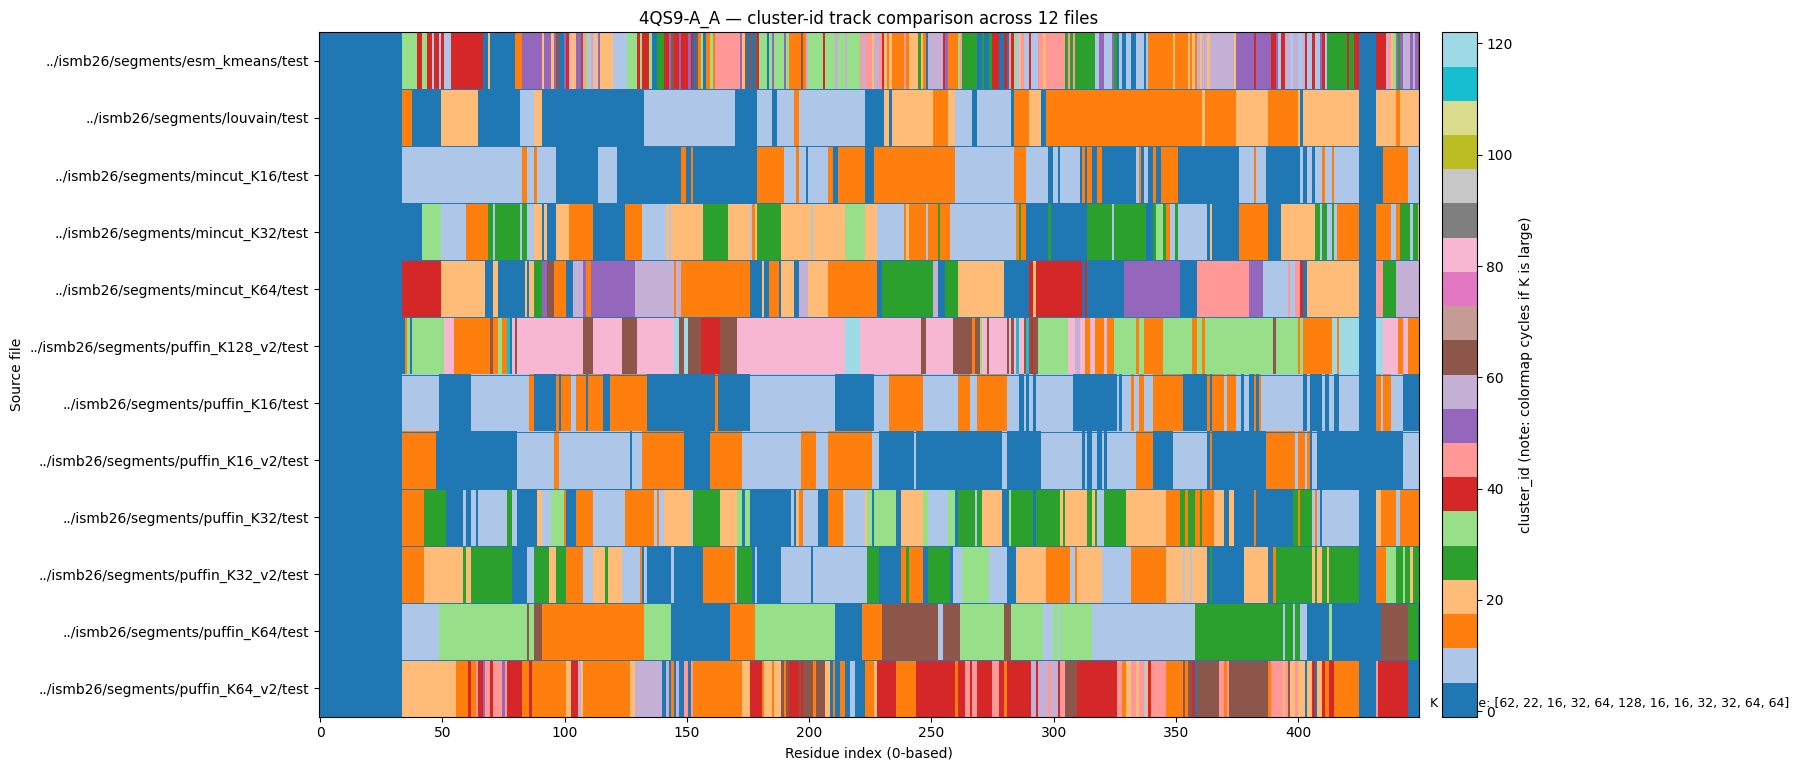

In [184]:
pdb_id = "3HZG-A_A"
# Option A: let it pick a pdb_id that exists in >=2 files
pdb_id, labels, mat = compare_pdb_id_across_files(df, pdb_id=None, seed_per_file=None)

# Option B: specify one
# pdb_id, labels, mat = compare_pdb_id_across_files(df, pdb_id="3ONG-B_B", seed_per_file=0)


In [185]:
import os
import glob
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ----------------------------
# Helpers: parsing CSV fields
# ----------------------------
def _parse_int_list(s):
    if pd.isna(s):
        return []
    s = str(s).strip().strip('"').strip("'")
    if not s:
        return []
    return [int(x.strip()) for x in s.split(",") if x.strip() != ""]

def parse_pdb_chain(pdb_id_str: str):
    """
    Examples:
      "3ONG-B_B" -> pdb="3ONG", chain="B"
      "1AD3-A_A" -> pdb="1AD3", chain="A"

    If chain can't be parsed, returns chain=None.
    """
    s = str(pdb_id_str)
    pdb = s[:4].upper()
    chain = None
    # try the common "3ONG-B_B" pattern
    if "-" in s:
        after = s.split("-", 1)[1]
        if after:
            chain = after[0].upper()
    return pdb, chain

def load_many_csvs(csv_glob_pattern: str) -> pd.DataFrame:
    paths = sorted(glob.glob(csv_glob_pattern))
    if not paths:
        raise FileNotFoundError(f"No CSV files match: {csv_glob_pattern}")

    dfs = []
    for p in paths:
        df = pd.read_csv(p)
        df["__source_file__"] = p
        dfs.append(df)

    all_df = pd.concat(dfs, ignore_index=True)

    needed = {"pdb_id", "n_residues", "residue_ids", "cluster_ids", "K", "__source_file__"}
    missing = needed - set(all_df.columns)
    if missing:
        raise ValueError(f"Missing columns: {missing}")

    # Add parsed pdb4 + chain columns for convenience
    parsed = all_df["pdb_id"].apply(parse_pdb_chain)
    all_df["pdb4"] = parsed.apply(lambda x: x[0])
    all_df["chain"] = parsed.apply(lambda x: x[1])

    return all_df

def pick_one_row_per_file(df_sub: pd.DataFrame, seed: int | None = 0):
    """
    df_sub already filtered to a pdb_id (and optionally chain).
    Returns list of pandas Series (one row per unique source file).
    """
    rows = []
    for src, g in df_sub.groupby("__source_file__"):
        if len(g) == 1:
            rows.append(g.iloc[0])
        else:
            rows.append(g.sample(n=1, random_state=seed).iloc[0])
    rows = sorted(rows, key=lambda r: r["__source_file__"])
    return rows

def row_to_dense_cluster_track(row: pd.Series, n_res_target: int) -> np.ndarray:
    n_res = int(row["n_residues"])
    residue_ids = _parse_int_list(row["residue_ids"])
    cluster_ids = _parse_int_list(row["cluster_ids"])

    if len(residue_ids) != len(cluster_ids):
        raise ValueError(
            f"Length mismatch: residue_ids={len(residue_ids)} vs cluster_ids={len(cluster_ids)} "
            f"(pdb_id={row['pdb_id']}, file={row['__source_file__']})"
        )

    # Build track over [0..n_res_target-1]
    track = np.full(n_res_target, fill_value=-1, dtype=int)

    # assumes residue_ids are 0-based indices
    for r, c in zip(residue_ids, cluster_ids):
        if 0 <= r < n_res_target:
            track[r] = int(c)

    return track


# ----------------------------
# InterPro parsing -> intervals
# ----------------------------
def extract_interpro_intervals(interpro_json: dict, pdb4: str, chain: str | None):
    """
    Returns list of dict intervals:
      {
        "accession": "IPR....",
        "name": "...",
        "type": "domain" | "family" | ...,
        "start0": int,   # 0-based inclusive
        "end0": int,     # 0-based inclusive
      }

    Uses entry_protein_locations fragments (start/end; 1-based) -> converts to 0-based.
    Filters by matching chain if chain is provided.
    """
    pdb4 = pdb4.upper()
    if pdb4 not in interpro_json:
        return []

    intervals = []
    results = interpro_json[pdb4].get("results", [])
    for entry in results:
        md = entry.get("metadata", {})
        acc = md.get("accession", "NA")
        name = md.get("name", "NA")
        typ = md.get("type", "NA")

        for st in entry.get("structures", []):
            # filter chain
            st_chain = st.get("chain", None)
            if chain is not None and st_chain is not None and st_chain.upper() != chain.upper():
                continue

            for loc in st.get("entry_protein_locations", []):
                for frag in loc.get("fragments", []):
                    # InterPro uses 1-based inclusive coords in these fragments
                    s = frag.get("start", None)
                    e = frag.get("end", None)
                    if s is None or e is None:
                        continue
                    start0 = int(s) - 1
                    end0 = int(e) - 1
                    if end0 >= start0:
                        intervals.append(
                            dict(accession=acc, name=name, type=typ, start0=start0, end0=end0)
                        )

    # Deduplicate identical intervals
    uniq = {}
    for itv in intervals:
        key = (itv["accession"], itv["type"], itv["start0"], itv["end0"])
        uniq[key] = itv
    return list(uniq.values())


# ----------------------------
# Making annotation tracks
# ----------------------------
def build_annotation_tracks_per_accession(intervals, n_res):
    """
    One track per InterPro accession (binary 0/1).
    Returns:
      tracks: (n_tracks, n_res) int8
      labels: list[str]
    """
    by_acc = {}
    meta = {}
    for itv in intervals:
        acc = itv["accession"]
        by_acc.setdefault(acc, []).append(itv)
        meta[acc] = (itv["type"], itv["name"])

    tracks = []
    labels = []
    for acc in sorted(by_acc.keys()):
        t = np.zeros(n_res, dtype=np.int8)
        for itv in by_acc[acc]:
            s = max(0, itv["start0"])
            e = min(n_res - 1, itv["end0"])
            if e >= s:
                t[s : e + 1] = 1
        typ, name = meta[acc]
        labels.append(f"{typ} | {acc} | {name}")
        tracks.append(t)

    if not tracks:
        return np.zeros((0, n_res), dtype=np.int8), []
    return np.vstack(tracks), labels

def _pack_intervals(intervals):
    """
    Interval packing to avoid overlaps:
    returns list of "lanes"; each lane is a list of intervals that do not overlap.
    Greedy by start coordinate.
    """
    intervals = sorted(intervals, key=lambda x: (x["start0"], x["end0"]))
    lanes = []
    lane_ends = []  # end0 of last interval in lane

    for itv in intervals:
        placed = False
        for i, last_end in enumerate(lane_ends):
            if itv["start0"] > last_end:  # strict non-overlap
                lanes[i].append(itv)
                lane_ends[i] = itv["end0"]
                placed = True
                break
        if not placed:
            lanes.append([itv])
            lane_ends.append(itv["end0"])
    return lanes

def build_annotation_tracks_by_type_packed(intervals, n_res):
    """
    Groups intervals by InterPro 'type' (domain/family/active_site/etc.),
    then packs overlaps into multiple lanes per type.

    Each lane is a categorical track:
      0 = empty, >0 = annotation index within that type (color-coded)
    Returns:
      tracks: (n_lanes, n_res) int32
      labels: list[str] (one per lane)
      lane_legends: list[list[str]] (per lane, mapping of idx->label)
    """
    by_type = {}
    for itv in intervals:
        by_type.setdefault(itv["type"], []).append(itv)

    tracks = []
    labels = []
    lane_legends = []

    for typ in sorted(by_type.keys()):
        lanes = _pack_intervals(by_type[typ])

        # Within each lane, encode different accessions as different integers
        for lane_i, lane in enumerate(lanes, start=1):
            t = np.zeros(n_res, dtype=np.int32)
            # map accession -> small integer
            accs = sorted({itv["accession"] for itv in lane})
            acc2idx = {acc: j + 1 for j, acc in enumerate(accs)}  # start at 1

            legend = ["(empty)"]
            # make readable legend items
            for acc in accs:
                # pick a representative name
                rep = next(itv for itv in lane if itv["accession"] == acc)
                legend.append(f"{acc} | {rep['name']}")

            for itv in lane:
                s = max(0, itv["start0"])
                e = min(n_res - 1, itv["end0"])
                if e >= s:
                    t[s : e + 1] = acc2idx[itv["accession"]]

            tracks.append(t)
            labels.append(f"InterPro {typ} (lane {lane_i}/{len(lanes)})")
            lane_legends.append(legend)

    if not tracks:
        return np.zeros((0, n_res), dtype=np.int32), [], []
    return np.vstack(tracks), labels, lane_legends


# ----------------------------
# Plotting: cluster + interpro
# ----------------------------
def plot_clusters_and_interpro(
    df_all: pd.DataFrame,
    interpro_json: dict,
    pdb_id_full: str,
    seed_per_file: int | None = 0,
    annotation_mode: str = "type_packed",   # "type_packed" or "per_accession"
    show_basename: bool = True,
):  
    
    pdb4, chain = parse_pdb_chain(pdb_id_full)
    print(f"Parsed pdb4={pdb4}, chain={chain} from pdb_id_full={pdb_id_full}")
    # Filter CSV rows to this exact pdb_id_full if present; otherwise match by pdb4+chain
    sub = df_all[df_all["pdb_id"] == pdb_id_full].copy()
    if sub.empty:
        sub = df_all[(df_all["pdb4"] == pdb4) & (df_all["chain"] == chain)].copy()
    if sub.empty:
        raise ValueError(f"No CSV rows found for pdb_id_full={pdb_id_full} (pdb4={pdb4}, chain={chain})")

    print(f"Found {len(sub)} rows for pdb_id_full={pdb_id_full} (pdb4={pdb4}, chain={chain}) across {sub['__source_file__'].nunique()} files.")
    rows = pick_one_row_per_file(sub, seed=seed_per_file)

    # Align length across files (max n_residues)
    n_target = max(int(r["n_residues"]) for r in rows)

    # Build cluster matrix
    cluster_tracks = []
    cluster_labels = []
    Ks = []
    for r in rows:
        try:
            cluster_tracks.append(row_to_dense_cluster_track(r, n_target))
            Ks.append(int(r["K"]))
        
            lab = os.path.dirname(r["__source_file__"])
            # lab = os.path.basename(r["__source_file__"]) if show_basename else r["__source_file__"]
            cluster_labels.append(lab)
        except Exception as e:
            print(f"Skipping row from {r['__source_file__']} due to error: {e}")
            continue
    cluster_mat = np.vstack(cluster_tracks) if cluster_tracks else np.zeros((0, n_target), dtype=int)

    # InterPro intervals -> annotation tracks
    intervals = extract_interpro_intervals(interpro_json, pdb4=pdb4, chain=chain)

    if annotation_mode == "per_accession":
        ann_mat, ann_labels = build_annotation_tracks_per_accession(intervals, n_target)
        ann_legends = None
    elif annotation_mode == "type_packed":
        ann_mat, ann_labels, ann_legends = build_annotation_tracks_by_type_packed(intervals, n_target)
    else:
        raise ValueError("annotation_mode must be 'type_packed' or 'per_accession'")

    # ---- Plot: two stacked panels (clusters, then InterPro) ----
    n_cluster = cluster_mat.shape[0]
    n_ann = ann_mat.shape[0]
    total_h = max(3.0, 0.55 * (n_cluster + n_ann) + 1.5)
    fig_w = max(12, min(28, n_target / 25))

    fig, (ax1, ax2) = plt.subplots(
        2, 1, figsize=(fig_w, total_h),
        gridspec_kw={"height_ratios": [max(1, n_cluster), max(1, n_ann)]},
        sharex=True
    )

    # --- clusters ---
    if n_cluster > 0:
        im1 = ax1.imshow(cluster_mat, aspect="auto", interpolation="nearest", cmap=plt.get_cmap("tab20"))
        ax1.set_yticks(range(n_cluster))
        ax1.set_yticklabels(cluster_labels)
        ax1.set_ylabel("CSV file (clusters)")
        ax1.set_title(f"{pdb_id_full} — cluster tracks across {n_cluster} CSV(s) | K per file: {Ks}")
        cbar1 = fig.colorbar(im1, ax=ax1, fraction=0.02, pad=0.01)
        cbar1.set_label("cluster_id (colormap cycles)")
        # mark unassigned (-1)
        for i in range(n_cluster):
            unassigned = np.where(cluster_mat[i] == -1)[0]
            if len(unassigned):
                ax1.vlines(unassigned, ymin=i - 0.5, ymax=i + 0.5, linewidth=0.3)
    else:
        ax1.text(0.5, 0.5, "No cluster tracks found", ha="center", va="center", transform=ax1.transAxes)
        ax1.set_axis_off()

    # --- annotations ---
    if n_ann > 0:
        # For binary tracks, a 2-color map would be nicer, but we keep it simple and default.
        # For packed tracks, values are categorical (>0).
        im2 = ax2.imshow(ann_mat, aspect="auto", interpolation="nearest", cmap=plt.get_cmap("tab20"))
        ax2.set_yticks(range(n_ann))
        ax2.set_yticklabels(ann_labels)
        ax2.set_ylabel("InterPro")
        ax2.set_xlabel("Residue index (0-based)")
        ax2.set_title(f"InterPro tracks ({annotation_mode}) | intervals={len(intervals)}")
        cbar2 = fig.colorbar(im2, ax=ax2, fraction=0.02, pad=0.01)
        cbar2.set_label("annotation id (per lane)")
    else:
        ax2.text(0.5, 0.5, "No InterPro annotations found for this PDB/chain", ha="center", va="center", transform=ax2.transAxes)
        ax2.set_xlabel("Residue index (0-based)")
        ax2.set_axis_off()

    plt.tight_layout()
    plt.show()

    # Optional: print lane legends for packed tracks (so you can interpret colors)
    if annotation_mode == "type_packed" and ann_legends:
        print("\nLegend per InterPro lane (value -> annotation):")
        for lab, leg in zip(ann_labels, ann_legends):
            # only print non-empty legend entries
            print(f"\n[{lab}]")
            for idx, txt in enumerate(leg):
                if idx == 0:
                    continue
                print(f"  {idx}: {txt}")

    return cluster_mat, cluster_labels, ann_mat, ann_labels






Parsed pdb4=2HVA, chain=A from pdb_id_full=2HVA-A_A
Found 12 rows for pdb_id_full=2HVA-A_A (pdb4=2HVA, chain=A) across 12 files.


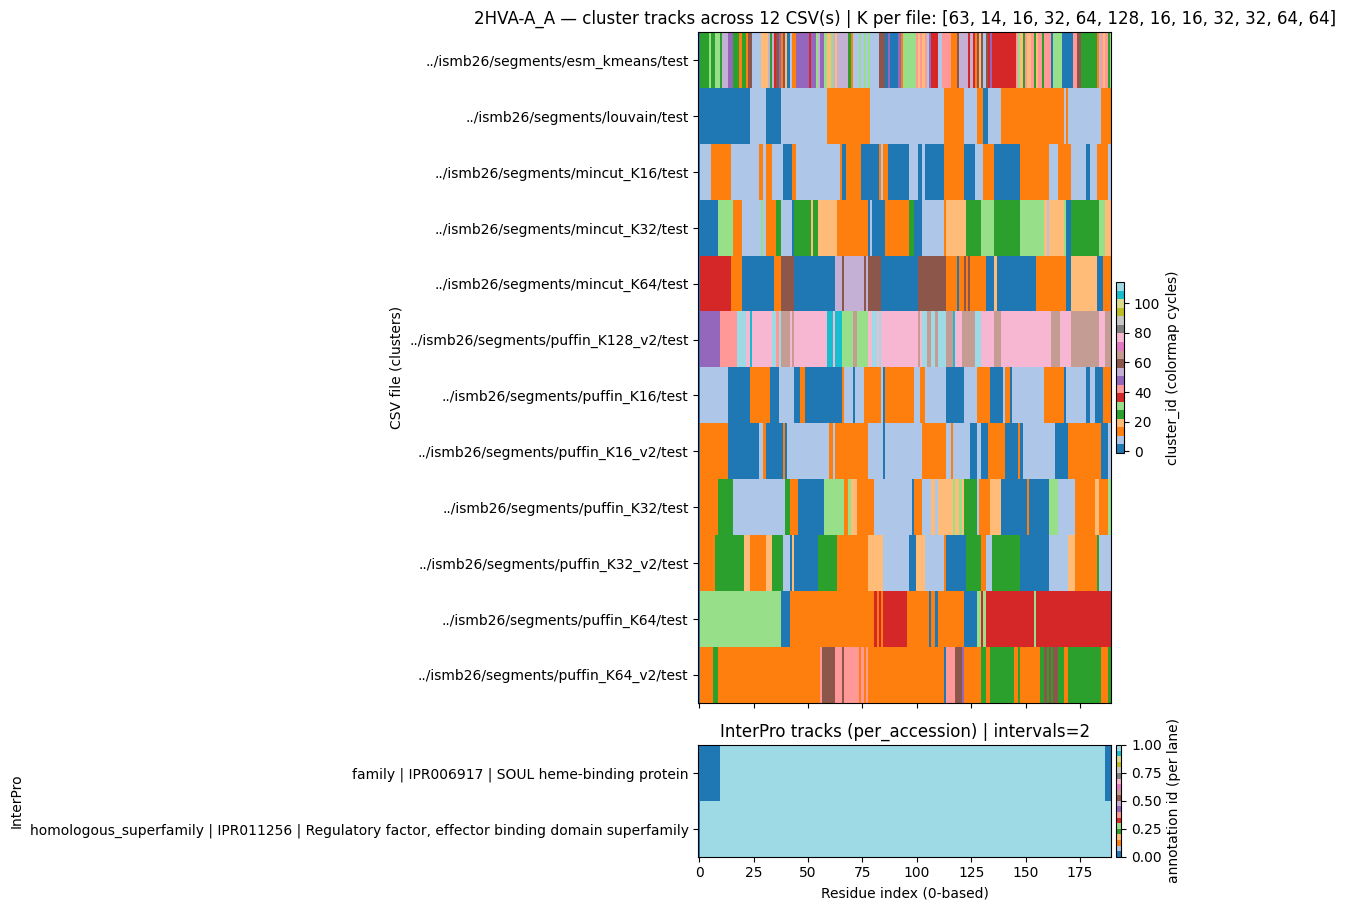

(array([[-1, 22, 22, ..., 41, 23, 29],
        [-1,  1,  1, ..., 14, 14, 14],
        [-1,  5,  5, ..., 13,  5,  5],
        ...,
        [-1, 15, 15, ...,  7,  7,  7],
        [-1, 33, 33, ..., 34, 34, 34],
        [-1, 16, 16, ..., 12, 22, 22]]),
 ['../ismb26/segments/esm_kmeans/test',
  '../ismb26/segments/louvain/test',
  '../ismb26/segments/mincut_K16/test',
  '../ismb26/segments/mincut_K32/test',
  '../ismb26/segments/mincut_K64/test',
  '../ismb26/segments/puffin_K128_v2/test',
  '../ismb26/segments/puffin_K16/test',
  '../ismb26/segments/puffin_K16_v2/test',
  '../ismb26/segments/puffin_K32/test',
  '../ismb26/segments/puffin_K32_v2/test',
  '../ismb26/segments/puffin_K64/test',
  '../ismb26/segments/puffin_K64_v2/test'],
 array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1, 1,

In [187]:
import json
with open("../data/GeneOntology/test_interpro.json", "r") as f:
    interpro = json.load(f)
#df = df[df["pdb_id"] == "4K95-A_A"]
sample = df.sample(n=1).iloc[0]



# 3) Plot for a specific protein row id like "3ONG-B_B"
plot_clusters_and_interpro(
    df_all=df,
    interpro_json=interpro,
    pdb_id_full=sample["pdb_id"],
    seed_per_file=0,
    annotation_mode="per_accession",   # or "per_accession"
)


In [119]:
import pandas as pd
df = pd.read_csv("../ismb26/results/segment_func_reports/puffin_K64/valid/unit_knn_go_enrichment_valid_per_query.csv")

test_protein = df["query_protein"].sample(1, random_state=0).item()


In [145]:
import pandas as pd

def expand_segments(df):
    rows = []

    for _, r in df.iterrows():
        pdb_id = r["pdb_id"]

        # split residue and cluster lists
        residues = [int(x) for x in str(r["residue_ids"]).split(",")]
        clusters = [int(x) for x in str(r["cluster_ids"]).split(",")]

        assert len(residues) == len(clusters), \
            f"Length mismatch for {pdb_id}: {len(residues)} vs {len(clusters)}"

        for resi, seg in zip(residues, clusters):
            rows.append({
                "pdb_id": pdb_id,
                "segment_id": seg,
                "residue_index": resi
            })

    return pd.DataFrame(rows)

df = pd.read_csv("../ismb26/segments/puffin_K64/valid/valid_residue_assignments.csv")

seg_res_df = expand_segments(df)
seg_res_df


,pdb_id,segment_id,residue_index
0,4MID-A_A,13,10
1,4MID-A_A,13,11
2,4MID-A_A,13,12
3,4MID-A_A,13,13
4,4MID-A_A,13,14
...,...,...,...
812376,5LDO-A_A,13,172
812377,5LDO-A_A,13,173
812378,5LDO-A_A,13,174
812379,5LDO-A_A,13,175


In [146]:
seg_res_df[seg_res_df.duplicated(["pdb_id","residue_index"])]

,pdb_id,segment_id,residue_index
4850,6QHB-A_A,34,186
4851,6QHB-A_A,34,186
4882,6QHB-A_A,34,220
22054,1VR1-H_H,13,60
22055,1VR1-H_H,13,60
...,...,...,...
768684,1H3P-L_L,30,27
768685,1H3P-L_L,30,27
782976,2KYM-A_A,30,43
811117,4OW4-A_A,13,76


In [147]:
from pathlib import Path

def pdb_chain_path(pdb_id: str, pdb_dir="../data/pdb_chain"):
    """
    4MID-A_A → pdb_chain/4MID-A.pdb
    """
    base = pdb_id.split("-")[0].split('_')[0].lower() 
    return Path(pdb_dir) / f"{base}_{pdb_id.split('_')[-1]}.pdb"

from Bio.PDB import PDBParser
from Bio.PDB import MMCIFParser

def load_structure(pdb_id, pdb_dir="../data/pdb_chain"):
    path = pdb_chain_path(pdb_id, pdb_dir)
    if not path.exists():
        cif_path = path.with_suffix(".cif")
        print("Trying MMCIF path:", cif_path)
        if cif_path.exists():
            parser = MMCIFParser(QUIET=True)
            structure = parser.get_structure(pdb_id, cif_path)
            return structure
        else:
            raise FileNotFoundError(f"PDB file not found: {path}")
    parser = PDBParser(QUIET=True)
    structure = parser.get_structure(pdb_id, path)
    return structure

def residue_atom_map(structure, chain_id):
    """
    Returns { residue_index (int) : [atom serials] }
    """
    res2atoms = {}
    for model in structure:
        for chain in model:
            if chain.id != chain_id:
                continue
            for res in chain:
                if res.id[0] != " ":   # skip HETATM
                    continue
                resi = res.id[1]
                res2atoms[resi] = [a.get_serial_number() for a in res]
    return res2atoms


In [157]:
id = "3HZG-A_A"
seg_res_df_prot = seg_res_df[seg_res_df.pdb_id == id]

structure = load_structure(id)
res2atoms = residue_atom_map(structure, chain_id=id.split("_")[0]) 
seg_res_df_prot

Trying MMCIF path: ../data/pdb_chain/3hzg_A.cif


,pdb_id,segment_id,residue_index
380867,3HZG-A_A,1,2
380868,3HZG-A_A,1,3
380869,3HZG-A_A,1,4
380870,3HZG-A_A,1,5
380871,3HZG-A_A,1,6
...,...,...,...
381107,3HZG-A_A,62,242
381108,3HZG-A_A,62,243
381109,3HZG-A_A,62,244
381110,3HZG-A_A,62,245


In [154]:
from pathlib import Path
import numpy as np
enrich_path = Path("../ismb26/results/segment_func_reports/puffin_K64/valid/unit_knn_go_enrichment_valid_per_query.csv")
enrich_df = pd.read_csv(enrich_path)
enrich_df = enrich_df[enrich_df["tag"] == "knn_true"].copy()
enrich_df["global_seg_index"] = enrich_df["query_seg"].astype(int)

meta_path = Path("../ismb26/segments/puffin_K64/valid/valid_segment_metadata.csv")
meta_df = pd.read_csv(meta_path)
meta_df["segment_k"] = meta_df["segment_k"].astype(int)
meta_df["global_seg_index"] = meta_df["global_seg_index"].astype(int)


segment_ids = sorted(seg_res_df_prot["segment_id"].astype(int).unique())
pdb_meta = (
    meta_df[meta_df["pdb_id"] == id]
    .rename(columns={"segment_k": "segment_id"})
    [["segment_id", "global_seg_index", "n_residues_assigned"]]
)


segment_enrich = (
    pd.DataFrame({"segment_id": segment_ids})
    .merge(pdb_meta, on="segment_id", how="left")
    .merge(enrich_df, on="global_seg_index", how="left")
)


segment_enrich["best_pval"] = pd.to_numeric(segment_enrich["best_pval"], errors="coerce")
segment_enrich["minus_log10_best_pval"] = -np.log10(segment_enrich["best_pval"])
segment_enrich["minus_log10_best_pval"] = segment_enrich["minus_log10_best_pval"].replace([np.inf, -np.inf], np.nan)

segment_enrich = segment_enrich.sort_values("best_pval")

display_cols = [
    "segment_id", "global_seg_index", "n_residues_assigned",
    "neighbor_proteins", "unique_neighbor_proteins", "shared_go_frac_neighbors",
    "best_term", "best_pval", "best_odds_approx", "minus_log10_best_pval",
]
segment_enrich_display = segment_enrich[display_cols]
segment_enrich_display

seg2score = {
    int(row.segment_id): float(row.minus_log10_best_pval)
    for row in segment_enrich.itertuples()
    if pd.notna(row.minus_log10_best_pval)
}
seg2term = {
    int(row.segment_id): str(row.best_term)
    for row in segment_enrich.itertuples()
    if isinstance(row.best_term, str) and row.best_term.strip()
}

seg2score, seg2term


({13: 0.8274101770715427, 1: 0.5111971004382584},
 {13: 'GO:0050660', 1: 'GO:0016741'})

In [134]:
enrich_df

,tag,query_row,query_seg,query_protein,k,neighbor_proteins,unique_neighbor_proteins,neff_neighbor_proteins,go_entropy_neighborhood,top1_protein_share,top3_protein_share,has_go,hit_any_shared_go,shared_go_frac_neighbors,best_term,best_pval,best_odds_approx,global_seg_index
0,knn_true,9367,86732,1VJZ-A,50,50,50,50.000000,0.942660,0.020000,0.060000,1,1,0.240000,GO:0004553,8.460301e-08,9.501548,86732
1,knn_true,8828,82144,3HZG-A,50,50,50,50.000000,0.938917,0.020000,0.060000,1,1,0.060000,GO:0016741,3.081789e-01,1.845833,82144
2,knn_true,7224,67554,3M3P-A,50,50,50,50.000000,0.903024,0.020000,0.060000,0,0,NaN,NaN,NaN,NaN,67554
3,knn_true,255,2366,3HDH-A,50,50,50,50.000000,0.962470,0.020000,0.060000,1,1,0.080000,GO:0016616,1.249026e-02,4.926482,2366
4,knn_true,16996,155891,4Q7R-A,50,43,43,39.360656,0.934271,0.040816,0.122449,0,0,NaN,NaN,NaN,NaN,155891
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,knn_true,3404,31475,3IJ5-A,50,48,48,47.078431,0.856184,0.040816,0.081633,1,1,0.250000,GO:0016779,6.050324e-03,6.179842,31475
4996,knn_true,3242,30118,4ZKU-A,50,50,50,50.000000,0.950354,0.020000,0.060000,0,0,NaN,NaN,NaN,NaN,30118
4997,knn_true,3279,30434,3JYU-A,50,49,49,49.000000,0.949445,0.020408,0.061224,1,1,0.122449,GO:0008234,5.446407e-02,5.826087,30434
4998,knn_true,14661,134046,2NWH-A,50,50,50,50.000000,0.945779,0.020000,0.060000,1,1,0.060000,GO:0016772,6.093193e-01,0.963603,134046


In [138]:
seg_res_df.to_records(index=False)

rec.array([],
          dtype=[('pdb_id', 'O'), ('segment_id', '<i8'), ('residue_index', '<i8')])

In [155]:
import py3Dmol
from pathlib import Path

SEGMENT_COLORS = [
    "#e41a1c",  # red
    "#377eb8",  # blue
    "#4daf4a",  # green
    "#984ea3",  # purple
    "#ff7f00",  # orange
    "#ffff33",  # yellow
    "#a65628",  # brown
    "#f781bf",  # pink
    "#999999",  # gray
    "#66c2a5",
    "#fc8d62",
    "#8da0cb",
    "#e78ac3",
    "#a6d854",
    "#ffd92f",
]

def segment_color(seg_id: int) -> str:
    return SEGMENT_COLORS[seg_id % len(SEGMENT_COLORS)]



def load_structure_py3dmol(struct_path: str, width=800, height=600):
    struct_path = Path(struct_path)

    if not struct_path.exists():
        raise FileNotFoundError(f"Missing structure file: {struct_path}")

    # Read raw structure text
    struct_str = struct_path.read_text()

    # Detect format
    suffix = struct_path.suffix.lower()
    if suffix in [".pdb"]:
        fmt = "pdb"
    elif suffix in [".cif", ".mmcif"]:
        fmt = "cif"
    else:
        raise ValueError(f"Unsupported structure format: {suffix}")

    view = py3Dmol.view(width=width, height=height)
    view.addModel(struct_str, fmt)
    view.setStyle({"cartoon": {"color": "lightgray"}})
    view.zoomTo()

    return view

def color_segments(
    view,
    pdb_chain: str,
    seg_res_df
):
    chain = pdb_chain.split("-")[1][0]

    # for seg_id, g in seg_res_df.groupby("segment_id"):
    #     residues = sorted(g["residue_index"].unique().tolist())
    #     hue = (seg_id * 37) % 360

    #     view.setStyle(
    #         {"chain": chain, "resi": residues},
    #         {"cartoon": {"color": f"hsl({hue},70%,50%)"}}
    #     )
    #      view.setStyle({"cartoon": {"color": "#dddddd"}})

    # Color each segment
    for seg_id, g in seg_res_df.groupby("segment_id"):
        residues = sorted(g["residue_index"].unique().tolist())
        
        color = segment_color(int(seg_id))

        view.setStyle(
            {"chain": chain, "resi": residues},
            {"cartoon": {"color": color}}
        )
        view.addLabel(
            f"Seg {seg_id}\n−log10 p=3.2",
            {"resi": residues[len(residues)//2]},
            {"backgroundColor": "white", "fontSize": 11}
        )




view = load_structure_py3dmol("../data/pdb_chain/6qhb_A.cif")
color_segments(view, "6QHB-A_A", seg_res_df)
view.show()



3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [ ]:
import py3Dmol
from pathlib import Path
import html
from typing import Dict, Any

SEGMENT_COLORS = [
    "#e41a1c", "#377eb8", "#4daf4a", "#984ea3", "#ff7f00",
    "#ffff33", "#a65628", "#f781bf", "#999999", "#66c2a5",
    "#fc8d62", "#8da0cb", "#e78ac3", "#a6d854", "#ffd92f",
]

def segment_color(seg_id: int) -> str:
    return SEGMENT_COLORS[int(seg_id) % len(SEGMENT_COLORS)]

from typing import List, Tuple

def contiguous_runs(residues: List[int]) -> List[Tuple[int, int]]:
    """
    residues: iterable of residue indices (can be unsorted, with duplicates)
    returns: list of (start, end) contiguous runs, sorted by start
    """
    r = sorted(set(int(x) for x in residues))
    if not r:
        return []
    runs = []
    start = prev = r[0]
    for x in r[1:]:
        if x == prev + 1:
            prev = x
        else:
            runs.append((start, prev))
            start = prev = x
    runs.append((start, prev))
    return runs



def format_run_labels(seg_id: int, runs: List[Tuple[int,int]], max_runs: int = 6) -> List[str]:
    """
    max_runs: keep legend readable; increase if you want all runs
    """
    labels = []
    for i, (a, b) in enumerate(runs[:max_runs], start=1):
        labels.append(f"Seg {seg_id} · run {i}: {a}-{b}")
    if len(runs) > max_runs:
        labels.append(f"Seg {seg_id} · +{len(runs)-max_runs} more runs")
    return labels


def segment_runs_from_df(seg_res_df, seg_id: int) -> Tuple[List[int], List[Tuple[int,int]]]:
    res = seg_res_df.loc[seg_res_df["segment_id"] == seg_id, "residue_index"].astype(int).tolist()
    residues = sorted(set(res))
    runs = contiguous_runs(residues)
    return residues, runs

def _make_legend_html(rows: List[Dict[str, Any]], title="Segments"):
    items_html = []
    for r in rows:
        # runs text lines
        run_lines = "".join(
            f"<div style='margin-left:20px;color:#333;'>• {html.escape(line)}</div>"
            for line in r["run_lines"]
        )

        items_html.append(
            f"""
            <div style="margin:6px 0;">
              <div style="display:flex;align-items:center;gap:8px;">
                <div style="width:12px;height:12px;border-radius:3px;background:{r['color']};border:1px solid #222;"></div>
                <div style="font-family:system-ui,-apple-system,Segoe UI,Roboto,Arial;
                            font-size:12px;line-height:1.2;color:#111;">
                  <b>Seg {r['seg_id']}</b>
                  <span style="color:#444;margin-left:6px;">{html.escape(r['score_str'])}</span>
                </div>
              </div>
              {run_lines}
            </div>
            """
        )

    legend = f"""
    <div style="
      position:absolute; right:12px; top:12px; z-index:9999;
      background:rgba(255,255,255,0.92);
      border:1px solid #ccc; border-radius:10px;
      padding:10px 12px; max-width:360px; max-height:460px; overflow:auto;
      box-shadow:0 4px 16px rgba(0,0,0,0.12);
    ">
      <div style="font-family:system-ui,-apple-system,Segoe UI,Roboto,Arial;
                  font-size:13px;font-weight:700;margin-bottom:6px;">
        {html.escape(title)}
      </div>
      {''.join(items_html)}
    </div>
    """
    return legend

def view_segments_with_labels(
    pdb_chain: str,
    seg_res_df,
    pdb_dir="pdb_chain",
    *,
    seg2score=None,          # dict: segment_id -> float (e.g., -log10 p)
    seg2term=None,           # optional dict: segment_id -> "GO:...."
    label_mode="score",      # "score" | "term+score" | "none"
    max_runs_per_seg=8,      # keep legend readable
    width=960,
    height=520,
):
    seg2score = seg2score or {}
    seg2term = seg2term or {}

    pdb_id, chain = pdb_chain.split("_")
    print(pdb_chain, "-> pdb_id:", pdb_id, "chain:", chain)
    pdb_path = Path(pdb_dir) / f"{pdb_chain}.cif"
    if not pdb_path.exists():
        print("CIF not found, trying PDB format...")
        # fallback to pdb
        pdb_path = Path(pdb_dir) / f"{pdb_chain}.pdb"
    if not pdb_path.exists():
        print("PDB not found either.")
        raise FileNotFoundError(f"Missing structure for {pdb_chain}: tried .cif and .pdb in {pdb_dir}")


    model_format = "cif" if pdb_path.suffix.lower() == ".cif" else "pdb"
    pdb_str = pdb_path.read_text()

    view = py3Dmol.view(width=width, height=height)
    view.addModel(pdb_str, model_format)

    # Base style
    #view.setStyle({"cartoon": {"color": "#d9d9d9"}})
    view.setStyle({}, {"cartoon": {"color": "lightgray"}})
    view.zoomTo()

    legend_rows = []

    # Draw segments + per-seg label
    for seg_id, g in seg_res_df.groupby("segment_id"):
        residues, runs = segment_runs_from_df(seg_res_df, seg_id)
        print(f"Segment {seg_id}: residues={residues}, runs={runs}")
        # color the whole segment (all residues, interleaving is fine)
        view.setStyle(
            {"chain": chain, "resi": residues},
            {"cartoon": {"color": segment_color(seg_id)}}
        )

    #            # Build score text for legend
    #     score_str = ""
    #     if label_mode != "none":
    #         term = seg2term.get(int(seg_id), "")
    #         sc   = seg2score.get(int(seg_id), None)
    #         if label_mode == "score":
    #             score_str = f"-log10p={sc:.2f}" if sc is not None else ""
    #         elif label_mode == "term+score":
    #             if term and sc is not None:
    #                 score_str = f"{term}  ·  -log10p={sc:.2f}"
    #             elif term:
    #                 score_str = f"{term}"
    #             elif sc is not None:
    #                 score_str = f"-log10p={sc:.2f}"

    #     # Run lines (supports non-contiguous membership)
    #     run_lines = []
    #     for i, (a, b) in enumerate(runs[:max_runs_per_seg], start=1):
    #         run_lines.append(f"run {i}: {a}-{b}")
    #     if len(runs) > max_runs_per_seg:
    #         run_lines.append(f"+{len(runs)-max_runs_per_seg} more runs")

    #     legend_rows.append(
    #         dict(
    #             seg_id=int(seg_id),
    #             color=segment_color(seg_id),
    #             score_str=score_str,
    #             run_lines=run_lines,
    #         )
    #     )

    # legend_rows.sort(key=lambda x: x["seg_id"])
    # view.addCustom(_make_legend_html(legend_rows, title=f"{pdb_chain} segment legend"))

    # view.zoomTo()
    # view.render()
    return view



pdb_chain_short = "3hzg_A"
# view segments with GO enrichment labels
view = view_segments_with_labels(
    pdb_chain=pdb_chain_short,
    seg_res_df=seg_res_df_prot,
    pdb_dir="../data/pdb_chain",
    seg2score=seg2score,
    seg2term=seg2term,
    label_mode="term+score",
)
view.show()


3hzg_A -> pdb_id: 3hzg chain: A
Segment 1: residues=[2, 3, 4, 5, 6, 84, 85, 86, 87, 88, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 176, 177, 178, 179, 180, 181], runs=[(2, 6), (84, 88), (114, 136), (176, 181)]
Segment 13: residues=[13, 14, 51, 52, 53, 54, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 77, 100, 101, 186, 187, 188, 189, 190, 225, 226], runs=[(13, 14), (51, 54), (59, 75), (77, 77), (100, 101), (186, 190), (225, 226)]
Segment 30: residues=[15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 55, 56, 57, 58, 76], runs=[(15, 50), (55, 58), (76, 76)]
Segment 34: residues=[102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 17

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

,pdb_id,segment_id,residue_index
0,4MID-A_A,13,10
1,4MID-A_A,13,11
2,4MID-A_A,13,12
3,4MID-A_A,13,13
4,4MID-A_A,13,14
...,...,...,...
812376,5LDO-A_A,13,172
812377,5LDO-A_A,13,173
812378,5LDO-A_A,13,174
812379,5LDO-A_A,13,175


In [87]:
def write_pymol_segment_script(
    pdb_id,
    seg_res_df,
    pdb_dir="pdb_chain",
    out_pml="segments.pml"
):
    pdb, chain = pdb_id.split("_")[0].split("-")
    pdb_file = f"{pdb_dir}/{pdb}-{chain}.pdb"

    lines = []
    lines.append(f"load {pdb_file}, mol")
    lines.append("hide everything")
    lines.append("show cartoon")
    lines.append("color gray70, mol")

    for seg_id, g in seg_res_df.groupby("segment_id"):
        residues = "+".join(str(r) for r in sorted(g["residue_index"].unique()))
        sel_name = f"seg_{seg_id}"
        color = (seg_id * 37) % 360
        lines.append(
            f"select {sel_name}, chain {chain} and resi {residues}"
        )
        lines.append(f"color {color}, {sel_name}")

    lines.append("bg_color white")
    lines.append("zoom")

    Path(out_pml).write_text("\n".join(lines))
